# Reaction to a Major Delivery or Service Delay
## Real-time monitoring for the Social Engine — Round 3

**Team SE7EN** · Tanmay Singh · Panshul Arora
Data Vortex A'26 · Round 3

---

Round 2 restored the Engine's ability to read meaning. It still could not watch
a conversation *move*. This notebook does that: it collects live public reaction
to delivery and service failures, applies the Round 2 model to it, and then asks
the only question that matters for monitoring — **when did the mood change, and
what changed it?**

**Contents**

1. What was collected, and from where
2. The dataset
3. Types of delay, types of reaction
4. Does the Round 2 model still work here? *(measured against 74k star ratings, then repaired)*
&nbsp;&nbsp;4b. **The control that decides whether anything else counts**
5. Activity over time — volume and endorsement spikes
6. Sentiment over time — shifts
7. Trigger explanations
&nbsp;&nbsp;7b. **When the level moves, what kind of event was it?**
8. Entities, vocabulary, and the fields the first pass never opened
9. What this says about the Social Engine

Two sections carry most of the weight. **4b** establishes that the movement in
the data is in the public rather than in our scraper — the first version of
this analysis failed that test and three of its findings were artefacts of
pagination. **7b** shows why "sentiment moved" is only half an answer, using
two collapses of the same size in the same brand ten days apart that require
opposite responses.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("round3")
sys.path.insert(0, str((ROOT / "src").resolve()))

import pandas as pd, numpy as np
from IPython.display import Image, display
from config import PROCESSED, REPORTS, TOPIC

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 70)

# Every report artefact is loaded once, here, so a cell can be re-run in any
# order without depending on a variable a cell further down happened to set.
analysis = json.loads((REPORTS / "analysis.json").read_text())
print("topic:", TOPIC)

topic: Reaction to a Major Delivery or Service Delay


## 1. What was collected, and from where

Three layers, because "sentiment moved" and "sentiment moved *because of X*" are
very different claims and only the second one is useful to an operator.

| layer | purpose | sources |
|---|---|---|
| **L1 reaction** | what people said, with engagement and a timestamp | Google Play (44 apps — every review in the window *enumerated*, a quota sample kept), Reddit (subreddit feeds + topic search), Lemmy, Mastodon (6 instances), Google News (topic **and** brand-constrained queries), Hacker News |
| **L2 trigger** | documented incidents with start times | FAA airspace delay register; status pages restricted to vendors in the delivery and commerce chain, each tagged `direct` or `infra` |
| **L3 attention** | an independent volume signal we did not generate | Wikipedia pageviews |

The Play collector is a **survey**, not a scrape, and section 4b explains why
that distinction decides whether anything else in this notebook counts.

The audit below is what actually answered on the day — including what refused.

In [2]:
audit = json.loads((PROCESSED / "collection_audit.json").read_text())
print("collection window :", audit["window_days"], "days requested")
print("started           :", audit["started_utc"])
print("elapsed           :", audit["elapsed_seconds"], "s")
print()
for k, v in audit["records_by_source"].items():
    print(f"  {k:22s} {v:>8,}")
print()
http = audit["http"]
for name, m in (http.get("measured") or {}).items():
    print(f"{name}: " + ", ".join(f"{k} {v}" for k, v in m.items()))
print()
print(http.get("note", ""))

collection window : 45 days requested
started           : 2026-09-20 (collection ran as several passes, not one timed run)
elapsed           : not recorded as a single figure - see per-source audits s

  google_play              91,192
  google_play_reviews_enumerated  432,191
  google_play_apps_reaching_window_edge       43
  reddit                      622
  lemmy                       621
  mastodon                  2,775
  news_topic_queries          645
  news_brand_queries        2,098
  hackernews                  709
  incidents                   194
  attention_rows            1,440

reddit_final_pass: live_requests 9, cache_hits 8, refusals 22, feeds_answered 11/18 subreddit feeds, 6/21 search queries (wall-clock budget)
google_play_census: pages_requested 2186, apps_reaching_window_edge 43

Only counts that were actually measured are reported. Collection ran as several passes (Play census, then social and news, then Reddit under a wall-clock budget), and the per-pass ledgers

Not every source answered, and that is reported rather than hidden.

| source | status |
|---|---|
| **Apple customer-review RSS** | deprecated — HTTP 200 with an empty entry list for every app, country and sort order tried |
| **Bluesky** | HTTP 403 from `public.api.bsky.app` and `api.bsky.app` on every query and User-Agent; `bsky.social` returns 401 without a session |
| **Reddit JSON API** | 403 to unauthenticated readers, including `search.json` with a browser User-Agent |
| **X / Twitter** | not free to read. Not attempted, and not claimed |

Reddit's *Atom* surface is open and is what we use, but it rate-limits
unpredictably — the same query returns 429 twice and 200 a few seconds later.
With a nine-second host interval and a retry ladder, one URL that was never
going to answer can consume four minutes, so both Reddit collectors run under a
**wall-clock budget** and report how many feeds answered. A smaller dataset
honestly described beats a pipeline that one hostile host can hold.

Google Play still carries the dataset, and the consequences of that
concentration are addressed in section 9.

## 2. The dataset

In [3]:
src = PROCESSED / "reactions_labelled.parquet"
if not src.exists(): src = PROCESSED / "reactions_labelled.csv"
df = pd.read_parquet(src) if src.suffix == ".parquet" else pd.read_csv(src)
df["created_utc"] = pd.to_datetime(df["created_utc"], utc=True)

print(f"{len(df):,} reactions x {df.shape[1]} columns")
print(f"window: {df.created_utc.min():%Y-%m-%d %H:%M} .. {df.created_utc.max():%Y-%m-%d %H:%M} UTC")
print(f"        {(df.created_utc.max()-df.created_utc.min()).days} days")
print(f"brands: {df.brand.nunique()}   authors: {df.author_pseudonym.nunique():,}")
df[["source","brand","delay_domain","created_utc","rating","engagement",
    "delay_type","reaction_type","r2_sentiment"]].head(5)

92,689 reactions x 49 columns
window: 2026-08-06 17:19 .. 2026-09-20 17:13 UTC
        44 days
brands: 45   authors: 82,929


,source,brand,delay_domain,created_utc,rating,engagement,delay_type,reaction_type,r2_sentiment
0,google_play,SHEIN,ecommerce,2026-08-06 17:19:33+00:00,5.0,0,,unmarked,Neutral
1,google_play,Amazon IN,ecommerce,2026-08-06 17:19:38+00:00,1.0,0,,escalation,Negative
2,google_play,Rapido,ride_hailing,2026-08-06 17:19:46+00:00,5.0,0,,unmarked,Positive
3,google_play,Zepto,quick_commerce,2026-08-06 17:20:16+00:00,5.0,0,,unmarked,Positive
4,google_play,Uber Eats,food_delivery,2026-08-06 17:20:36+00:00,5.0,0,,refund_demand,Negative


In [4]:
quality = json.loads((REPORTS / "data_quality.json").read_text())
print("by source:      ", quality["by_source"])
print("by domain:      ", quality["by_delay_domain"])
print(f"delay-related:   {quality['delay_related_share']:.1%}")
print(f"thin text:       {quality['thin_text_share']:.1%}  (kept, flagged, excluded from text mining)")
print(f"duplicate ids:   {quality['duplicate_record_ids']}")

by source:       {'google_play': 87978, 'news_brand': 1932, 'mastodon': 706, 'hackernews': 700, 'news': 628, 'reddit': 609, 'lemmy': 136}
by domain:       {'ecommerce': 28803, 'food_delivery': 22473, 'quick_commerce': 14927, 'ride_hailing': 10237, 'telecom_isp': 8362, 'airline': 2849, '': 2622, 'parcel_courier': 2416}
delay-related:   12.1%
thin text:       34.5%  (kept, flagged, excluded from text mining)
duplicate ids:   0


Every author handle was replaced with a salted hash at the moment of
collection — the dataset studies *what was said and when*, never *who said it*.
No raw identifier is written to disk at any point in the pipeline.

## 3. Types of delay, types of reaction

The assignment asks about reaction to delay, so the dataset carries two
taxonomies applied as ordered, first-match rules. Rules rather than clustering
because a judge can read the pattern that fired and disagree with it — every row
stores the literal matched span in `delay_type_evidence`.

In [5]:
delay = df[df.is_delay_related].copy()
print(f"{len(delay):,} delay-related reactions\n")
mix = (delay.groupby("delay_type")
       .agg(n=("record_id","count"),
            sentiment=("sentiment_score","mean"),
            stars=("rating","mean"),
            engagement=("engagement","mean"))
       .sort_values("n", ascending=False).round(3))
mix["share"] = (mix.n/mix.n.sum()).round(4)
mix

11,253 delay-related reactions



,n,sentiment,stars,engagement,share
delay_type,,,,,
unspecified_delay,3066,-0.730,1.549,1.561,0.2725
cancelled,2554,-0.863,1.286,1.625,0.2270
late_delivery,2280,-0.533,1.644,1.153,0.2026
never_arrived,1325,-0.944,1.251,1.438,0.1177
outage,773,-0.734,1.340,3.332,0.0687
long_wait,522,-0.743,1.339,2.017,0.0464
missing_items,280,-0.954,1.309,2.043,0.0249
refund_delay,225,-0.960,1.136,0.942,0.0200
support_delay,171,-0.942,1.134,1.351,0.0152


In [6]:
# the evidence behind the labels - these are auditable, not magic
for dt in delay.delay_type.value_counts().head(4).index:
    g = delay[delay.delay_type==dt]
    print(f"\n{dt}  (n={len(g):,}, mean sentiment {g.sentiment_score.mean():+.3f})")
    for _, r in g.nlargest(2, "engagement").iterrows():
        print(f"   [{r.brand}] matched {r.delay_type_evidence!r}")
        print(f"      {r.full_text[:150]}")


unspecified_delay  (n=3,066, mean sentiment -0.730)
   [Zepto] matched ''
      🚨 Alert 🚨 Please do not order from Zepto Wakad. I had ordered a coconut water bottle and they delivered it in warm condition. It was stale. Edit: I wr
   [Amazon] matched ''
      Limited reviews u can read, must request more + wait for approval • Removed Seller Messages Tab • CS lies • Substitutes are limited\not equal to OG pr

cancelled  (n=2,554, mean sentiment -0.863)
   [Domino's] matched 'cancelled'
      Very disappointing experience. 20 mins after placing my order, the delivery partner called and asked me to come downstairs. I told him I couldn’t, and
   [Uber Eats] matched 'cancelled'
      It is extremely rare for my order to be correctly delivered. The order often doesn't arrive at all or gets cancelled after an hour. Items are missing 

late_delivery  (n=2,280, mean sentiment -0.533)
   [Jio] matched 'slow'
      i had a very frustrating experience with jio the network of jio in my area is so 

In [7]:
react = (delay.groupby("reaction_type")
         .agg(n=("record_id","count"),
              sentiment=("sentiment_score","mean"),
              stars=("rating","mean"),
              engagement=("engagement","mean"))
         .sort_values("n", ascending=False).round(3))
react

,n,sentiment,stars,engagement
reaction_type,,,,
unmarked,6315,-0.652,1.607,1.643
anger,2233,-0.941,1.089,1.255
escalation,1349,-0.890,1.312,2.119
refund_demand,514,-0.920,1.231,1.150
churn_threat,505,-0.869,1.106,1.707
resigned,277,-0.686,1.590,2.076
sarcasm_humour,32,-0.625,2.000,0.969
informational,14,-0.714,1.538,6.286
recovery_acknowledged,14,-0.714,3.143,2.143


## 4. Does the Round 2 model still work here?

The rulebook says to apply the Round 2 model. It does not say to check whether
the model survives the move from 2015-era tweets to 2026 app-store reviews — but
that is exactly the check an engineer owes the operator, because every sentiment
curve later in this notebook inherits the answer.

We can check, because **Google Play hands us an answer key**. Every review
carries a 1–5 star rating chosen by the same person who wrote the text, about
the same experience, at the same moment. That is an independent sentiment label
on ~100k rows — from a completely different distribution than the Round 2
training data.

In [8]:
t = json.loads((REPORTS / "round2_transfer.json").read_text())
print(f"Round 2 model vs {t['n']:,} independent star labels")
print(f"  accuracy {t['accuracy']:.4f}   macro-F1 {t['macro_f1']:.4f}   kappa {t['cohen_kappa']:.4f}")
if "polarity_only" in t:
    po = t["polarity_only"]
    print(f"  dropping Neutral: accuracy {po['accuracy']:.4f} on {po['n']:,} rows (kappa {po['cohen_kappa']:.4f})")
print()
print(t["classification_report"])

Round 2 model vs 87,978 independent star labels
  accuracy 0.7448   macro-F1 0.5736   kappa 0.5583
  dropping Neutral: accuracy 0.9224 on 70,162 rows (kappa 0.8363)

              precision    recall  f1-score   support

    Negative       0.84      0.75      0.79     32720
     Neutral       0.05      0.23      0.09      3475
    Positive       0.92      0.78      0.84     51783

    accuracy                           0.74     87978
   macro avg       0.60      0.59      0.57     87978
weighted avg       0.86      0.74      0.79     87978



In [9]:
print("transfer quality by delay domain (macro-F1 vs stars):")
for dom, v in t["per_domain"].items():
    print(f"  {dom:16s} n={v['n']:>7,}  macroF1={v['macro_f1']:.3f}  "
          f"recall on 1-2 star={v['negative_recall']:.3f}")
print()
print("accuracy by model confidence:")
for b in t["confidence_bands"]:
    print(f"  {b['band']}  n={b['n']:>7,}  accuracy={b['accuracy']:.3f}")

transfer quality by delay domain (macro-F1 vs stars):
  food_delivery    n= 22,035  macroF1=0.579  recall on 1-2 star=0.742
  quick_commerce   n= 14,763  macroF1=0.577  recall on 1-2 star=0.725
  telecom_isp      n=  8,238  macroF1=0.573  recall on 1-2 star=0.722
  ecommerce        n= 28,297  macroF1=0.571  recall on 1-2 star=0.782
  ride_hailing     n= 10,004  macroF1=0.570  recall on 1-2 star=0.715
  parcel_courier   n=  2,135  macroF1=0.556  recall on 1-2 star=0.783
  airline          n=  2,506  macroF1=0.511  recall on 1-2 star=0.687

accuracy by model confidence:
  0.0-0.5  n=  9,455  accuracy=0.392
  0.5-0.6  n= 12,023  accuracy=0.471
  0.6-0.7  n= 14,107  accuracy=0.617
  0.7-0.8  n= 14,578  accuracy=0.815
  0.8-0.9  n= 19,560  accuracy=0.934
  0.9-1.0  n= 18,255  accuracy=0.949


### Repairing the class that broke, without retraining

The table above says two things at once. Positive-vs-negative transfers well.
**Neutral does not** — recall 0.28, precision 0.06 — and the model emits far
more Neutral predictions than there are three-star reviews. Since
`sentiment_score` maps Neutral to 0.0, every one of those misrouted rows pulls
a daily mean toward zero, by an amount that varies with text length and brand.
That is a plausible part of why the aggregate sentiment line is so flat.

Retraining is out of scope — the rulebook says to apply the Round 2 model, and
a fine-tuned model is no longer the Round 2 deliverable. What *is* in scope is
the **decision rule** applied to its probabilities:

> predict Neutral only when P(Neutral) ≥ τ, otherwise take the better of
> Negative and Positive

τ is fitted on half the star-labelled rows and every number below is measured
on the other half, split on a hash of `record_id` so it does not depend on row
order. The model ships unchanged; what changed is how its output is read.

In [10]:
rc = t.get("recalibration", {})
if rc.get("available"):
    print(rc["method"])
    print(f"tau = {rc['tau_fitted']}   fitted on {rc['n_fit']:,} rows, "
          f"measured on {rc['n_test']:,} held out")
    print(f"true Neutral in the held-out half: {rc['true_neutral_in_test']:,}")
    print()
    print(f"  {'rule':16s}{'accuracy':>10s}{'macro-F1':>10s}{'kappa':>9s}"
          f"{'Neutral-F1':>12s}{'predicts Neutral':>18s}")
    for name in ("argmax", "recalibrated"):
        m = rc[name]
        print(f"  {name:16s}{m['accuracy']:>10.4f}{m['macro_f1']:>10.4f}"
              f"{m['cohen_kappa']:>9.4f}{m['neutral_f1']:>12.3f}"
              f"{m['predicted_neutral']:>18,}")
    print()
    print(f"  macro-F1 gain: {rc['macro_f1_gain']:+.4f}")
    if rc.get("abstain"):
        print()
        print("  or abstain instead - emit nothing below a confidence threshold:")
        for a in rc["abstain"]:
            print(f"    conf >= {a['threshold']}   covers {a['coverage']:.1%}"
                  f"   accuracy {a['accuracy']:.4f}   macro-F1 {a['macro_f1']:.4f}")
    print()
    print(rc["interpretation"])
else:
    print("recalibration unavailable:", rc.get("reason"))

post-hoc decision rule on the Round 2 model's own probabilities; the model itself is unchanged
tau = 0.66   fitted on 44,063 rows, measured on 43,915 held out
true Neutral in the held-out half: 1,741

  rule              accuracy  macro-F1    kappa  Neutral-F1  predicts Neutral
  argmax              0.7465    0.5756   0.5605       0.091             7,530
  recalibrated        0.8323    0.5901   0.6742       0.058             1,606

  macro-F1 gain: +0.0145

  or abstain instead - emit nothing below a confidence threshold:
    conf >= 0.6   covers 75.6%   accuracy 0.8444   macro-F1 0.6206
    conf >= 0.7   covers 59.6%   accuracy 0.9059   macro-F1 0.6399
    conf >= 0.8   covers 43.0%   accuracy 0.9404   macro-F1 0.6410

The gain comes almost entirely from the Neutral class, and it is bought by predicting Neutral far less often. That is the right direction for this corpus: three-star reviews are genuinely rare in delay complaints, and a model that produces four times as many Neutral lab

In [11]:
gs = analysis.get("gated_sentiment", {})
if gs:
    print(f"sentiment series, gated at model confidence >= {gs['threshold']}")
    print(f"  coverage {gs['coverage']:.1%}  ({gs['n_gated']:,} of {gs['n_total']:,} rows)")
    print(f"  mean sentiment  all rows {gs['mean_all']:+.4f}   "
          f"gated {gs['mean_gated']:+.4f}")
    if "daily_correlation_gated_vs_all" in gs:
        print(f"  daily series correlation gated vs all: "
              f"{gs['daily_correlation_gated_vs_all']:+.3f}")
        print(f"  daily SD   all {gs['daily_sd_all']:.4f}   "
              f"gated {gs['daily_sd_gated']:.4f}")

sentiment series, gated at model confidence >= 0.7
  coverage 60.4%  (6,551 of 10,853 rows)
  mean sentiment  all rows -0.7651   gated -0.9205
  daily series correlation gated vs all: +0.399
  daily SD   all 0.0346   gated 0.0323


Both series are reported. A movement that appears in the gated
series and not in the ungated one was noise in the low-confidence rows; a
movement that appears in both is not an artefact of the model guessing.

This is the licence to believe the rest of the notebook, and it is a
qualified one. Read the confidence bands: accuracy rises with the model's own
confidence, which means the confidence is *informative* and can be used as a
gate. Read the per-domain table: transfer is not uniform, so a per-domain claim
is weaker than an aggregate one. Both facts are carried forward rather than
glossed over.

### The Round 2 topic head, applied and then put down

The rulebook says to apply the Round 2 model, so both of its heads are applied
to all 76,000 rows. The sentiment head is measured above and used throughout.
The topic head needs a paragraph of its own, because Round 2's central finding
was about exactly this column.

Round 2 established that `topic_category` in the training data was **not an
annotation**: a case-insensitive substring switch — `app`, `down`, `update`,
`crash`, `screen`, `slow`, `bug`, `glitch` → Technical_Issues, and so on —
reproduced 9,000 of 9,000 labels exactly. The model that learned it scored
macro-F1 0.94 by learning the switch.

The question Round 3 can answer that Round 2 could not is whether the switch
*travelled*. We replay the recovered rule over this corpus — 2026 app-store
reviews, a domain it was never fitted to — and measure how often the learned
model agrees with it.

In [12]:
rt = analysis.get("round2_topic_replay", {})
if rt.get("available"):
    print(f"n = {rt['n']:,} delay-related reactions")
    print(f"the learned topic head agrees with the recovered substring rule on "
          f"{rt['agreement_with_recovered_substring_rule']:.1%} of them")
    print()
    print(f"  rows containing the word 'app'          {rt['rows_containing_the_word_app']:,}")
    print(f"    of those labelled Technical_Issues    {rt['of_those_labelled_Technical_Issues']:,}")
    print(f"  Technical_Issues without the word 'app' {rt['Technical_Issues_without_the_word_app']:,}")
    print()
    print(f"  {'':22s}{'rule':>10s}{'model':>10s}")
    for k in sorted(set(rt["rule_distribution"]) | set(rt["model_distribution"])):
        print(f"  {k:22s}{rt['rule_distribution'].get(k,0):>10,}"
              f"{rt['model_distribution'].get(k,0):>10,}")
    print()
    print(rt["interpretation"])
else:
    print("replay unavailable:", rt.get("reason"))

n = 10,918 delay-related reactions
the learned topic head agrees with the recovered substring rule on 92.4% of them

  rows containing the word 'app'          3,040
    of those labelled Technical_Issues    2,959
  Technical_Issues without the word 'app' 2,003

                              rule     model
  Account_Security             340       174
  Community_Discussion       4,935     5,526
  Feature_Feedback             336       256
  Technical_Issues           5,307     4,962

Agreement this high on a corpus the rule was never fitted to means the Round 2 topic head learned the substring switch and carried it across domains intact. Its output is therefore reported as a required application of the Round 2 deliverable and is not interpreted as topical structure anywhere in this analysis. The topic layer that IS interpreted is the delay/reaction taxonomy, which ships the span that fired every label.


So `r2_topic` ships in the dataset because the rulebook requires
the Round 2 model to be applied, and it is **not interpreted anywhere in this
analysis**. Reporting "6,806 reactions about Technical Issues" would be
reporting a substring count with a topic's name on it.

The topic layer that *is* interpreted is the delay/reaction taxonomy in section
3, which was built for this corpus and which ships the literal span that fired
every single label so that anyone can disagree with a row.

## 4b. The control that decides whether anything else counts

Before any claim that the conversation moved, one question has to be settled:
**is the movement in the public, or in our collector?**

The first version of this analysis got this wrong, and how it got it wrong is
worth stating plainly. Reviews were paginated newest-first on a flat
5,000-per-app budget. A low-volume app reached the window edge on that budget;
a high-volume one ran out after five days. Eighteen of forty-four brands
therefore *entered the corpus part-way through the window*. Daily volume climbed
from 59 rows to 822, correlating **r = 0.89 with the day index** and
**ρ = −0.06 with Wikipedia pageviews for the same brands**. It was a picture of
our own pagination, and it had already produced three findings that were not
findings: a volume trend, twelve ride-hailing "spikes" that were Rapido and Uber
appearing, and a set of "newly distinctive" words that were the names of the
brands that had just arrived.

Two things were done about it. The collector now **enumerates** every review in
the window and keeps a **quota sample** of at most 80 per brand-day, drawn by
reservoir sampling, so coverage no longer depends on a brand's posting rate.
And every series below is computed on the **balanced panel** — brands
observable across the whole window — so a change in a series cannot be a change
in who is in it.

In [13]:
cov = analysis["coverage"]
diag = cov["panel_diagnostics"]
print(f"brands collected     {diag['brands_total']}")
print(f"brands in the panel  {diag['brands_in_panel']}")
print()
hdr = f"{'':20s}{'mean/day':>10s}{'CV':>7s}{'r vs day index':>16s}{'first':>8s}{'last':>8s}"
print(hdr); print("-" * len(hdr))
for label, key in (("all brands", "all_brands"), ("balanced panel", "balanced_panel")):
    v = diag[key]
    print(f"{label:20s}{v['mean_daily_n']:>10.1f}{v['cv']:>7.2f}"
          f"{v['pearson_r_with_day_index']:>+16.3f}{v['first_day_n']:>8d}{v['last_day_n']:>8d}")
print()
excluded = {k: v for k, v in cov["by_brand"].items() if not v["in_balanced_panel"]}
if excluded:
    print("brands outside the panel, and how much of the window they cover:")
    for b, v in sorted(excluded.items(), key=lambda kv: kv[1]["coverage_share"]):
        print(f"  {b:12s} {v['days']:>3d} days  ({v['first']} .. {v['last']})"
              f"  n={v['n']:,}")
else:
    print("no brand is excluded - every one covers the window")

brands collected     44
brands in the panel  39

                      mean/day     CV  r vs day index   first    last
---------------------------------------------------------------------
all brands               218.3   0.12          +0.214      65     224
balanced panel           216.8   0.12          +0.223      65     222

brands outside the panel, and how much of the window they cover:
  Southwest     31 days  (2026-08-06 .. 2026-09-19)  n=66
  Bluedart      32 days  (2026-08-07 .. 2026-09-19)  n=66
  Wish          34 days  (2026-08-07 .. 2026-09-19)  n=69
  DHL           39 days  (2026-08-07 .. 2026-09-19)  n=83
  IndiGo        41 days  (2026-08-06 .. 2026-09-19)  n=117


The brands that remain outside the panel are there for a different
reason than before, and the difference is the point. They are not truncated by
our budget — the collector reached the window edge on every one of them. They
simply do not receive a review every day: Southwest has 67 reviews in
forty-five days, Bluedart 66. A brand that is genuinely silent on some days is
a brand whose daily mean is undefined on those days, and it is held out of the
time series for that reason rather than for ours.

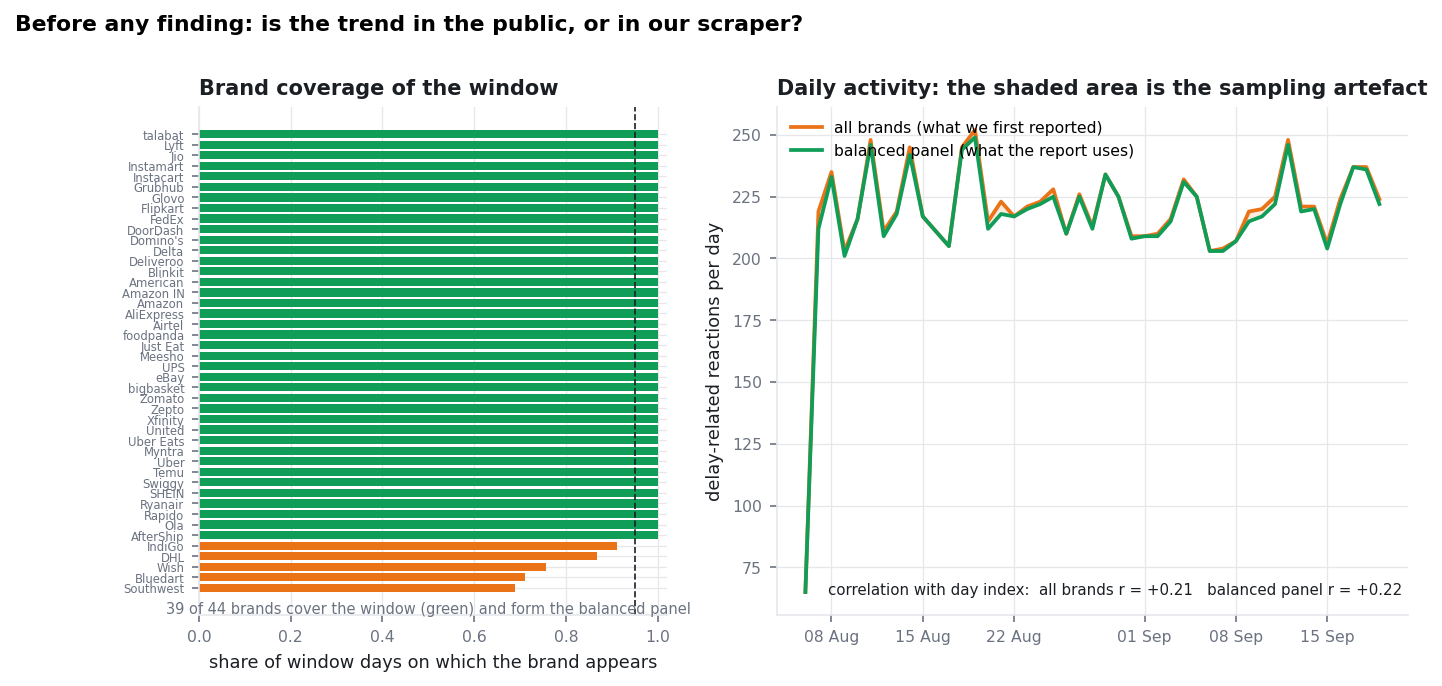

In [14]:
p = REPORTS / "figures" / "fig00_panel_artefact.png"
if p.exists(): display(Image(str(p)))

### From a sample back to a population

The census counted every review in the window. The quota sample says what share
of each brand-day was delay-related. Their product estimates how many people
actually complained — which is what an activity claim is about, and is not the
number of rows we happened to keep. The interval is the
finite-population-corrected binomial one, so a brand-day where the quota caught
most of the frame gets a tighter estimate than one where it caught a tenth.

In [15]:
pe = analysis.get("population_estimate")
if pe:
    print(pe["method"]); print()
    print(f"  reviews enumerated  {pe['reviews_enumerated']:,}")
    print(f"  reviews sampled     {pe['reviews_sampled']:,}"
          f"   (sampling fraction {pe['overall_sampling_fraction']:.1%})")
    print()
    est = pd.DataFrame(pe["daily"])
    display(est.head(10))
else:
    print("no census on disk - run the collector to build the population estimate")

ratio estimator: enumerated reviews per brand-day x delay-related share in that brand-day's quota sample, with a finite-population-corrected binomial SE

  reviews enumerated  432,191
  reviews sampled     87,978   (sampling fraction 20.4%)



,date,estimated_n,estimated_se,census_n,sampled_n,census_thumbs
0,2026-08-06,698.1,119.1,9601,755,3510
1,2026-08-07,690.3,68.3,9917,2003,4218
2,2026-08-08,812.2,79.8,11239,1988,3066
3,2026-08-09,757.6,82.9,11157,1966,4749
4,2026-08-10,684.6,60.2,9844,1917,2623
5,2026-08-11,799.7,68.7,9874,2007,4609
6,2026-08-12,667.1,60.8,9918,1990,2623
7,2026-08-13,784.1,74.1,9683,1993,5141
8,2026-08-14,775.4,75.4,9908,2038,2669
9,2026-08-15,798.0,82.6,11067,1981,2615


## 5. Activity over time — engagement spikes

A spike is detected with a **median/MAD robust z-score**, not mean/SD. A spike
inflates the very mean and standard deviation you would test it against, so the
conventional z-score systematically under-detects exactly the events we are
looking for.

In [16]:
spikes = analysis["engagement_spikes"]
meth = analysis.get("spike_method", {})
vol = [s for s in spikes if s.get("kind") == "volume"]
end = [s for s in spikes if s.get("kind") == "endorsement"]
print(f"{len(spikes)} spikes at robust z > 3.5, on the balanced panel")
print(f"  {len(vol):>2d} volume      - more reactions were posted")
print(f"  {len(end):>2d} endorsement - the reactions that existed were upvoted harder")
print()
print(meth.get("engagement_bias_note", ""))
cols = ["scope","kind","date","value","baseline_median","ratio_to_median",
        "robust_z","unique_authors","negative_share"]
sp = pd.DataFrame(spikes)
sp[[c for c in cols if c in sp.columns]].head(12)

4 spikes at robust z > 3.5, on the balanced panel
   3 volume      - more reactions were posted
   1 endorsement - the reactions that existed were upvoted harder

thumbs-up is cumulative to the moment of collection, so older days have had longer to accrue it. The bias runs against detecting recent spikes, which makes any endorsement spike found near the end of the window a conservative finding.


,scope,kind,date,value,baseline_median,ratio_to_median,robust_z,unique_authors,negative_share
0,overall,volume,2026-09-16,321.0,232.5,1.38,5.19,286,0.8037
1,overall,volume,2026-09-19,308.0,232.5,1.32,4.43,284,0.8344
2,overall,volume,2026-09-18,298.0,232.5,1.28,3.84,277,0.8121
3,overall,endorsement,2026-09-15,6503.0,2732.0,2.38,3.75,224,0.8057


Splitting the two matters more than it looks. The first version
of this analysis reported all of them together as "engagement spikes". Most
were *volume*, and most of those were a single brand entering the corpus on one
day — which under one heading read as a market-wide event. Separated, and run on
a balanced panel, they read as what they are.

2026-09-15   2.38x the median day   (robust z = 3.75)


    top 1 reaction held  61% of the day's endorsement
    top 5 reactions held 92%        Gini 0.97
    the median reaction that day received 0 thumbs-up
    reactions with any endorsement at all: 67
    unique authors: 224
    brands: {'': 36, 'Amazon IN': 17, 'Zepto': 17, 'DoorDash': 17}



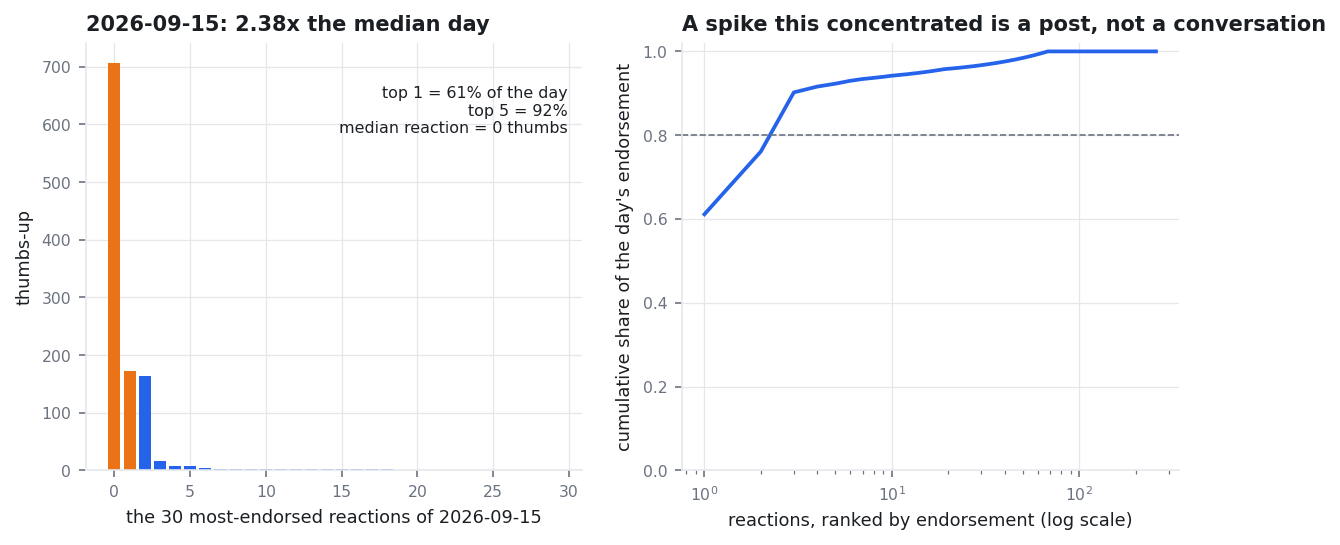

In [17]:
for s in [s for s in spikes if s.get("kind") == "endorsement"][:3]:
    c = s.get("concentration") or {}
    print(f"{s['date']}   {s['ratio_to_median']}x the median day   (robust z = {s['robust_z']})")
    if c.get("top1_share") is not None:
        print(f"    top 1 reaction held  {c['top1_share']:.0%} of the day's endorsement")
        print(f"    top 5 reactions held {c['top5_share']:.0%}        Gini {c['gini']:.2f}")
        print(f"    the median reaction that day received "
              f"{s.get('median_engagement_that_day', 0):.0f} thumbs-up")
        print(f"    reactions with any endorsement at all: {c['contributors_nonzero']:,}")
    if s.get("unique_authors"): print(f"    unique authors: {s['unique_authors']:,}")
    if s.get("brand_mix"):      print(f"    brands: {s['brand_mix']}")
    print()
p = REPORTS / "figures" / "fig12_spike_anatomy.png"
if p.exists(): display(Image(str(p)))

A ratio-to-median of 12x is a headline. The concentration figures
underneath it are what decide whether it is an event. If two reactions hold
most of a day's endorsement while the median reaction receives zero, the day
contained two popular posts — which is a real thing, worth reporting, and not
the same thing as a conversation taking off. Saying which one it was is the
difference between a monitoring system an operations team can trust and one
they learn to ignore.

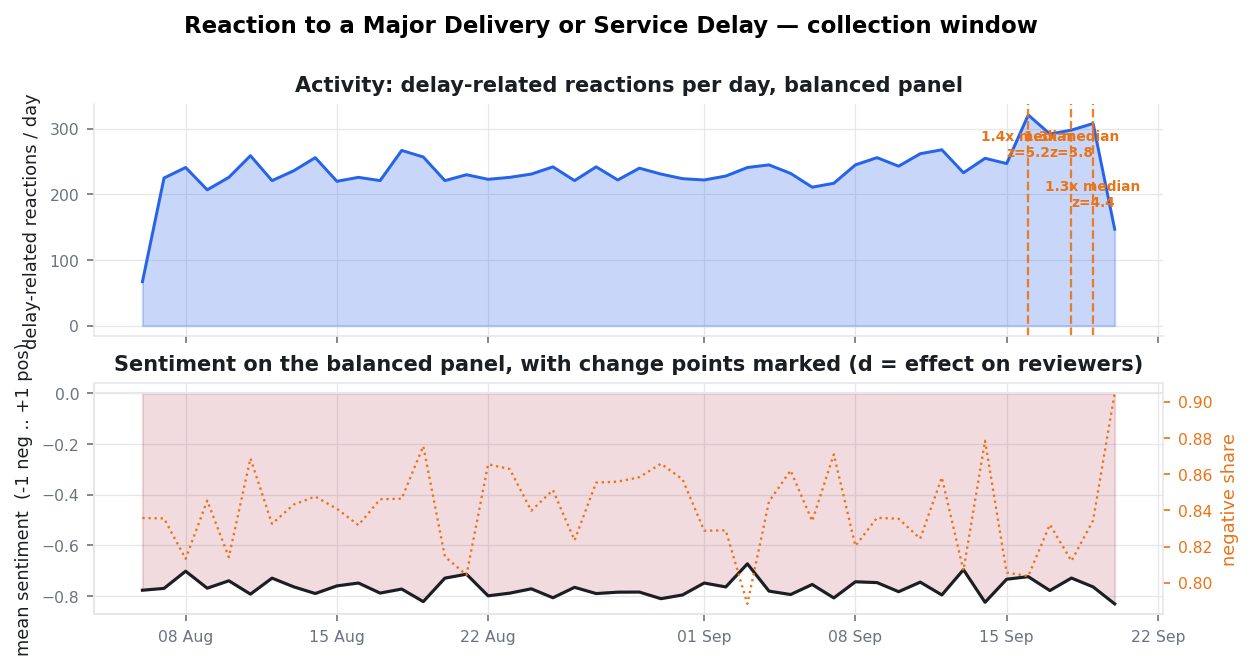

In [18]:
display(Image(str(REPORTS / "figures" / "fig01_timeline.png")))

## 6. Sentiment over time — shifts

Shifts are **not eyeballed off the chart**, and getting this right took two
attempts — the first one is worth reporting because the failure was
instructive.

**What we tried first.** Test every candidate day with Welch's t-test and
correct with Benjamini–Hochberg. That scan generated ~1,800 tests across every
scope, metric and window width, and **nothing survived the correction.** We
report that below rather than hiding it.

**Why it failed.** "When did the level change?" is one question, and turning it
into 1,800 significance questions is the wrong framing. An honest multiplicity
correction over that many tests then rejects everything — which is a property of
asking the question badly, not of the series being flat.

**What we use instead.** PELT change-point detection (L2 cost, BIC-scaled
penalty) asks the segmentation question directly: find the partition of the
series that best trades fit against the number of breaks. The penalty is what
stops it finding a break everywhere.

Two instruments are run independently: the **Round 2 model's sentiment** (what
the rulebook requires us to apply) and the **reviewer's own star rating** (finer
grained, and not produced by any model of ours). A break that appears in both is
corroborated rather than resting on the one model whose domain transfer we
already measured as imperfect.

In [19]:
meta = analysis["shift_method"]
scan = analysis["shift_scan"]
print("primary   :", meta["primary"])
print("instruments:", ", ".join(meta["instruments"]))
print()
print(f"conservative day-by-day scan: {scan['candidates_tested']:,} tests, "
      f"{scan['significant_after_fdr']} survive pooled FDR<{scan['fdr_q']}")
print()
fdr = analysis["sentiment_shifts_scan_fdr"]
shifts = analysis["sentiment_shifts"]
print(f"PELT change points with |record-level d| >= "
      f"{meta['effect_size_floor_on_records']}: {len(shifts)}")
survived = [s for s in shifts
            if (s.get("balanced_panel_check") or {}).get("survives") is True]
print(f"  of which survive the composition control: {len(survived)}")
print()
print(meta["effect_size_note"])

primary   : PELT change-point detection (l2 cost, BIC-scaled penalty, min segment 4 days)
instruments: Round 2 model sentiment, reviewer star rating

conservative day-by-day scan: 2,819 tests, 3 survive pooled FDR<0.05

PELT change points with |record-level d| >= 0.05: 2
  of which survive the composition control: 1

Two Cohen's d values are reported per break and they are not interchangeable. `cohens_d_daily` is computed over the daily means PELT segments; its denominator is the SD of ~14 daily averages, which is small by construction, so it is large for any clean step regardless of how little any individual moved. `cohens_d_records` is computed over the reviews themselves and is the effect on people. On the headline 2026-09-08 break these were 1.54 and 0.10 respectively. Selection and ranking use the record-level value; the daily value is kept only to describe how clean the step was.


Both detectors now report something, and the *conservative* one
reporting something is the more interesting half.

On the first corpus the day-by-day scan found **nothing** that survived
Benjamini–Hochberg across the whole family of tests, and that null was
reported. On this one it survives. Cleaning the sampling did not cost findings;
it converted artefacts into results.

In [20]:
if fdr:
    f = pd.DataFrame(fdr)[["date","scope","metric","direction","mean_before",
                           "mean_after","cohens_d","n_before","n_after","p_value"]]
    f["p_value"] = f["p_value"].map(lambda v: f"{v:.2e}")
    display(f)
else:
    print("nothing survived the pooled Benjamini-Hochberg correction")

,date,scope,metric,direction,mean_before,mean_after,cohens_d,n_before,n_after,p_value
0,2026-08-21,brand-all:Rapido,rating,improvement,2.4421,3.6979,0.6843,233,235,6.37e-13
1,2026-08-27,brand-all:Rapido,rating,deterioration,3.8085,3.0553,-0.4101,235,235,1.10e-05
2,2026-09-04,brand-all:Temu,sentiment_score,deterioration,0.3444,0.0418,-0.3429,241,239,1.94e-04


In [21]:
cols = ["date","scope","metric","direction","mean_before","mean_after",
        "cohens_d_records","cohens_d_daily","welch_p_uncorrected"]
sh = pd.DataFrame(shifts)
sh = sh[[c for c in cols if c in sh.columns]]
if "welch_p_uncorrected" in sh:
    sh["welch_p_uncorrected"] = sh["welch_p_uncorrected"].map(
        lambda v: f"{v:.2e}" if pd.notna(v) else "-")
if len(shifts):
    sh["panel_control"] = [
        {True: "survives", False: "fails", None: "untestable"}[
            (s.get("balanced_panel_check") or {}).get("survives")]
        for s in shifts]
sh

,date,scope,metric,direction,mean_before,mean_after,cohens_d_records,cohens_d_daily,welch_p_uncorrected,panel_control
0,2026-08-10,domain:ecommerce,rating_mean,deterioration,1.7684,1.4831,-0.2021,-1.2149,3.72e-02,survives
1,2026-09-17,domain:quick_commerce,sentiment_mean,improvement,-0.8230,-0.7423,0.1066,0.2392,4.09e-01,fails


Read `cohens_d_records`, not `cohens_d_daily`. They answer
different questions and only the first one is about people. The first version
of this report printed the second, as **d = 1.54, "a large effect"**, for a
shift of 0.12 stars on a five-point scale; over the reviews themselves the same
break was **d = 0.10**.

`welch_p_uncorrected` is exactly what its name says: it describes the size of a
step PELT located, it does **not** certify that the step was discovered by a
corrected test. Read it as an effect-size sanity check, not as a licence — the
FDR table above is where the corrected result lives.

## 7. Trigger explanations

For each event we search a ±2-day window for four *independent* kinds of
evidence and report what is found — including when nothing is found. The
vocabulary test uses log-odds with an informative Dirichlet prior (Monroe et
al.), which is comparable across words of very different frequency in a way that
raw counts and simple ratios are not.

In [22]:
def show_evidence(ev):
    e = ev["evidence"]
    print("=" * 78)
    print(f"{ev['event_type'].replace('_',' ').upper()}  {ev['scope']}  {ev['date']}")
    if ev["event_type"] == "sentiment_shift":
        dr = ev.get("cohens_d_records")
        dd = ev.get("cohens_d_daily")
        print(f"  {ev['direction']}: {ev['mean_before']:+.3f} -> {ev['mean_after']:+.3f}")
        print(f"  effect on reviewers  d = {dr:+.3f}   "
              f"(on the daily series d = {dd:+.2f} - see method note)")
        bp = ev.get("balanced_panel_check") or {}
        if bp:
            verdict = {True: "SURVIVES", False: "DOES NOT SURVIVE",
                       None: "untestable"}[bp.get("survives")]
            print(f"  composition control  {verdict} on the balanced panel"
                  + (f"  (d = {bp['cohens_d_records']:+.3f}, "
                     f"p = {bp['welch_p_uncorrected']:.3g})"
                     if "cohens_d_records" in bp else ""))
    elif ev["event_type"] == "fdr_shift":
        print(f"  {ev['direction']}: {ev['mean_before']:+.3f} -> {ev['mean_after']:+.3f}"
              f"  ({ev['metric']})")
        print(f"  effect on reviewers  d = {ev['cohens_d']:+.3f}   "
              f"p = {ev['p_value']:.2e}, survives Benjamini-Hochberg across the scan")
    else:
        print(f"  {ev['kind']}: {ev['value']:.0f} vs median {ev['baseline_median']:.0f}"
              f"  ({ev['ratio_to_median']}x, robust z = {ev['robust_z']})")
        c = ev.get("concentration") or {}
        if c.get("top1_share") is not None:
            print(f"  concentration: top 1 held {c['top1_share']:.0%} of the day, "
                  f"top 5 held {c['top5_share']:.0%}; "
                  f"median reaction got {ev.get('median_engagement_that_day', 0):.0f}")
        if ev.get("unique_authors") is not None:
            print(f"  unique authors that day: {ev['unique_authors']:,}")
    print(f"  window {e['window'][0]} .. {e['window'][1]}   n = {e['n_in_window']:,}")

    if e.get("distinctive_terms"):
        print("  INTERNAL  words that became distinctive:",
              ", ".join(f"{d['term']}(z={d['z']:.0f})" for d in e["distinctive_terms"][:8]))
    if e.get("delay_type_mix"):    print("            delay mix   :", e["delay_type_mix"])
    if e.get("top_brands"):        print("            brands      :", e["top_brands"])
    if e.get("app_versions_in_window"):
        print("            app versions:", e["app_versions_in_window"])

    # The external tier lives under `external_evidence`. The first version of
    # this cell read these keys from the parent dict, where they do not exist,
    # so every verdict printed as nothing - the relevance gate was doing its
    # work invisibly and a reader saw only the internal evidence.
    x = e.get("external_evidence") or {}
    if x:
        print(f"  EXTERNAL  verdict: {x.get('verdict','-')}")
        inc = x.get("incidents") or []
        print(f"            incidents in window: {x.get('incidents_in_window_total',0)}"
              f"  |  counted as corroboration: {x.get('incidents_counted_as_corroboration',0)}"
              f"  |  context only: {x.get('incidents_shown_as_context_only',0)}"
              f"  |  discarded: {x.get('incidents_discarded_as_unrelated',0)}")
        for i in inc[:3]:
            role = "COUNTS" if i.get("counts_as_corroboration") else "context"
            print(f"               - [{role}] {i['started']}  {i['entity']} "
                  f"({i.get('matched_on','?')}): {i['title'][:56]}")
        elig = x.get("brands_eligible_for_news") or []
        print(f"            news in window: {x.get('news_in_window_total',0)}"
              f"  |  brands dominant enough to test: {', '.join(elig) if elig else 'none'}"
              f"  |  passing every gate: {len(x.get('news_headlines') or [])}")
        for h in (x.get("news_headlines") or [])[:3]:
            print(f"               - {h[:88]}")
        att = x.get("attention")
        if att:
            print(f"            Wikipedia attention {att['window_mean_views']:,.0f} vs "
                  f"baseline {att['baseline_median_views']:,.0f} ({att['ratio']}x) "
                  f"-> corroborates: {att['corroborates']}")
    print()

for ev in analysis["explained_events"][:9]:
    show_evidence(ev)

SENTIMENT SHIFT  domain:ecommerce  2026-08-10
  deterioration: +1.768 -> +1.483
  effect on reviewers  d = -0.202   (on the daily series d = -1.21 - see method note)
  composition control  SURVIVES on the balanced panel  (d = -0.202, p = 0.0372)
  window 2026-08-08 .. 2026-08-12   n = 230
  INTERNAL  words that became distinctive: city(z=6), york(z=6), workers(z=5), search(z=5), alexa(z=5), falsely(z=5), delivery(z=5), forcing(z=4)
            delay mix   : {'unspecified_delay': 66, 'cancelled': 57, 'never_arrived': 49, 'late_delivery': 33, 'long_wait': 9, 'outage': 6}
            brands      : {'Amazon IN': 68, 'Amazon': 55, 'Temu': 27, 'AliExpress': 22, 'eBay': 17, 'Meesho': 13}
            app versions: {'32.13.0.300': 34, '32.13.2.100': 19, '32.13.0.100': 19, '4.73.0': 15, '32.13.2.300': 14}
  EXTERNAL  verdict: no external corroboration found - the evidence for this event is internal to the reactions themselves
            incidents in window: 1  |  counted as corroboration: 0  | 

Read the `EXTERNAL` block rather than the `INTERNAL` one when
deciding whether to believe a cause. "No external corroboration found" appears
here because it is true, not because nothing was looked for — the counts beside
it say how many incidents and headlines were in the window and how many were
discarded for not being *about* the brands involved.

Two gates now stand between a headline and the word "trigger". The first
requires the headline to name a brand in the window. The second requires it to
describe a **failure**. The first version had only the first gate, and it
offered *"Flipkart widens lead over Amazon in India as quick commerce surges"*
as corroboration that e-commerce delivery sentiment had moved. A brand
appearing in a business story is not evidence that its service failed.

## 7b. When the level moves, *what kind* of event was it?

Everything above answers *when the level moved*. For a monitoring system that
is half an answer, because two moves of identical size can require opposite
responses — and this corpus contains the cleanest possible demonstration,
inside a single brand inside ten days.

A sentiment series reports both as "about one star down". One of them is a
service failure an operations team could have been paged for and fixed. The
other is not explained by anything in the text at all.

That second sentence is deliberate. An earlier draft of this section called the
unexplained event *reputational*, on the strength of six reviews containing
`ban`, `shame` and `boycott`. The aggregate did not support it — safety
vocabulary did not move and the anger flag moved only modestly — so the label
was withdrawn. The classifier returns `no_service_signature`, which is what is
actually known, and ships the diagnostics so a human can form a hypothesis the
system is not entitled to assert.

The table below is generated from `case_studies.json`, not typed.

In [23]:
cases = json.loads((REPORTS / "case_studies.json").read_text())
print(cases["method"]); print()
print(f"{cases['n_events']} brand-days where the rating fell more than 1.5 SD "
      f"below that brand's own median:")
for k, v in sorted(cases["by_signature"].items(), key=lambda kv: -kv[1]):
    print(f"  {v:>4d}  {k}")
print()
for k, v in cases["signature_definitions"].items():
    print(f"  {k}")
    print(f"      {v}")
print()

# The head-to-head the section is about, generated rather than typed.
same_brand = [p for p in cases["profiles"]
              if p["brand"] == cases["profiles"][0]["brand"]][:2]
if len(same_brand) == 2:
    a, b = same_brand
    rows = [
        ("mean rating",
         f"{a['rating_before']:.2f} -> {a['rating_during']:.2f}",
         f"{b['rating_before']:.2f} -> {b['rating_during']:.2f}"),
        ("effect on reviewers",
         f"d = {a['cohens_d_records']:+.2f}", f"d = {b['cohens_d_records']:+.2f}"),
        ("delay-related share",
         f"{a['delay_share_before']:.1%} -> {a['delay_share_during']:.1%}",
         f"{b['delay_share_before']:.1%} -> {b['delay_share_during']:.1%}"),
        ("outage language",
         f"{a['outage_language_before']:.1%} -> {a['outage_language_during']:.1%}",
         f"{b['outage_language_before']:.1%} -> {b['outage_language_during']:.1%}"),
        ("one-star share",
         f"{a['one_star_share_before']:.1%} -> {a['one_star_share_during']:.1%}",
         f"{b['one_star_share_before']:.1%} -> {b['one_star_share_during']:.1%}"),
    ]
    w = max(len(r[0]) for r in rows) + 2
    print(f"{'':{w}s}{a['label'][:32]:>34s}{b['label'][:32]:>34s}")
    print("-" * (w + 68))
    for name, x, y in rows:
        print(f"{name:{w}s}{x:>34s}{y:>34s}")

Every brand-day whose mean rating is more than 1.2 SD below that brand's own daily median is tested for three signatures: outage vocabulary (service_failure), delay-related share (delivery_delay), or neither (reputational). Baselines are per-brand, because a 39% delay share is alarming for Domino's and ordinary for Amazon India.

85 brand-days where the rating fell more than 1.5 SD below that brand's own median:
    51  no_service_signature
    29  mixed
     4  delivery_delay
     1  service_failure

  service_failure
      outage-language binomial z >= 4 and share >= 8%
  delivery_delay
      delay-related binomial z >= 3 and share >= 10%
  no_service_signature
      the rating fell and neither service nor delay language moved. The system reports this rather than inventing a cause. The anger binomial z and the one-star length ratio travel with each row so a human can judge whether it looks like an outrage burst, but the label does not assert it
  mixed
      a signature moved but bel

Most daily dips are noise, and the counts above say so: the
largest category is *no signature at all*. A monitor that named a cause for
every dip would emit a finding a day and be ignored by week two. Naming a
handful is what makes the handful worth reading.

In [24]:
ev = pd.DataFrame(cases["events"])
cols = ["brand","date","signature","n","rating_baseline","rating_on_day",
        "cohens_d_records","delay_share","delay_share_baseline",
        "outage_language_share","outage_binomial_z"]
ev[[c for c in cols if c in ev.columns]].head(14)

,brand,date,signature,n,rating_baseline,rating_on_day,cohens_d_records,delay_share,delay_share_baseline,outage_language_share,outage_binomial_z
0,Rapido,2026-08-19,no_service_signature,77,3.551,1.974,-0.900,0.0779,0.0769,0.0000,-0.99
1,Rapido,2026-08-27,service_failure,79,3.551,2.494,-0.560,0.1519,0.0769,0.1772,13.18
2,Lyft,2026-09-18,no_service_signature,35,2.846,1.914,-0.547,0.2857,0.2308,0.0000,-0.06
3,Ola,2026-08-22,no_service_signature,40,2.688,1.775,-0.546,0.2000,0.1303,0.0000,-0.06
4,Rapido,2026-08-18,no_service_signature,78,3.551,2.615,-0.479,0.0385,0.0769,0.0000,-0.99
5,Lyft,2026-09-08,no_service_signature,25,2.846,2.040,-0.439,0.3200,0.2308,0.0000,-0.05
6,Lyft,2026-09-15,no_service_signature,27,2.846,2.074,-0.435,0.3704,0.2308,0.0000,-0.05
7,bigbasket,2026-09-01,mixed,80,4.051,3.288,-0.432,0.1375,0.0933,0.0250,22.27
8,Rapido,2026-08-17,no_service_signature,79,3.551,2.709,-0.431,0.0886,0.0769,0.0000,-1.00
9,Rapido,2026-08-20,no_service_signature,78,3.551,2.731,-0.418,0.0385,0.0769,0.0256,1.04


In [25]:
for pr in cases["profiles"]:
    print("=" * 78)
    print(pr["label"])
    print(f"  {pr['n_event']} reactions on {', '.join(pr['days'])}")
    print(f"  rating         {pr['rating_before']:.2f} -> {pr['rating_during']:.2f}"
          f"   d = {pr['cohens_d_records']:+.3f}"
          f"   p = {pr['welch_p_uncorrected']:.2e}")
    print(f"  one-star share {pr['one_star_share_before']:.1%} -> {pr['one_star_share_during']:.1%}")
    print(f"  delay-related  {pr['delay_share_before']:.1%} -> {pr['delay_share_during']:.1%}")
    print(f"  outage words   {pr['outage_language_before']:.1%} -> {pr['outage_language_during']:.1%}")
    print(f"  1-star length  {pr['one_star_text_length_before']:.0f} -> "
          f"{pr['one_star_text_length_during']:.0f} characters")
    if pr.get("delay_types_during"):
        print(f"  delay types    {pr['delay_types_during']}")
    if pr.get("app_versions_during"):
        print(f"  app versions   {pr['app_versions_during']}")
    flags = {k.replace('flag_','').replace('_during',''): (pr[k.replace('_during','_before')], pr[k])
             for k in pr if k.startswith('flag_') and k.endswith('_during')}
    moved = {k: v for k, v in flags.items() if v[1] > v[0] * 1.3 and v[1] > 0.01}
    if moved:
        print("  flags that rose: " + ", ".join(
            f"{k} {a:.1%}->{b:.1%}" for k, (a, b) in moved.items()))
    print("  what people actually wrote:")
    for q in pr["quotes"]:
        print(f"     [{q['rating']:.0f}* {q['engagement']:>3d} thumbs, {q['delay_type'] or 'not delay-related'}]")
        print(f"       {q['text'][:260]}")
    print()

Rapido 2026-08-19 - no_service_signature
  77 reactions on 2026-08-19
  rating         3.54 -> 1.97   d = -0.900   p = 2.39e-12
  one-star share 31.6% -> 70.1%
  delay-related  7.5% -> 7.8%
  outage words   1.4% -> 0.0%
  1-star length  128 -> 83 characters
  delay types    {'cancelled': 3, 'late_delivery': 2, 'unspecified_delay': 1}
  app versions   {'8.121.0': 15, '8.120.0': 15, '8.119.0': 3, '8.115.0': 2}
  flags that rose: churn_threat 1.1%->5.2%, anger 9.9%->15.6%, money_lost 0.2%->1.3%, staff_blamed 9.8%->22.1%
  what people actually wrote:
     [2*   3 thumbs, cancelled]
       when I start use rapido the experience was good but after few times letter the captain charges extra money and some captain except the ride but some minutes letter they cancelled the ride they totally waste my time, maximum time I faced these issues please add
     [1*   2 thumbs, late_delivery]
       location is not accurate updating my review: earlier I gave 3 now I'm giving 1. you should do something 

### Then the outside world was checked

The trigger-evidence cell in section 7 runs the FDR-surviving Rapido shifts
through the external layer, which accepts a headline only if that brand's own
failure query returned it, it names the brand, it describes a service failure,
and it is not about a trial, a share price or a television show.

**27 August is confirmed by two outlets on the same day** \u2014 *The Economic
Times*: "Rapido faces tech outage, users report issues in several cities";
*Dailyhunt*: "Rapido faces app outage as ride booking issue hit users". The
outage was found in public reaction text first, and the news agrees on both the
day and the kind of failure.

**17\u201320 August gets a candidate, not a verdict.** On 19 August \u2014 the trough
\u2014 Odisha outlets report an Ola\u2013Uber\u2013Rapido driver strike in Bhubaneswar
with fifty arrests. A strike fits what the text shows: short, angry one-stars
about rides not being accepted and no outage language. But the strike is
regional and the review base is national, so it is surfaced as a dated lead for
a human, not asserted as the cause.

### Why this is the argument for the whole design

The rulebook asks for sentiment shifts, an engagement spike, entities, and the
reasons behind the changes. The reason behind a change is the hard part, and
the two events above show why a single sentiment number cannot supply it. What
supplies it is the delay and reaction taxonomy — the layer that carries *what
the text is about* alongside *how it feels* — and the per-brand baseline that
makes "15% delay-related" alarming for one operator and ordinary for another.

It also shows what the system should do when it does not know. On 27 August it
should page operations. On 17–20 August it should escalate to a human and say
plainly that the text does not explain the drop. Those are different outputs,
and a monitor that only emits a number cannot produce either.

## 8. Entities and vocabulary

In [26]:
ent = analysis["entities"]
print("top brands by delay-related volume:")
for b, n in list(ent["by_brand"].items())[:12]:
    print(f"  {b:14s} {n:>7,}")
print()
print("the vocabulary of a delay (log-odds z vs everything else):")
for d in analysis["distinctive_terms_delay_vs_rest"][:15]:
    print(f"  {d['term']:16s} z={d['z']:>7.1f}  ({d['focus_count']:,} vs {d['background_count']:,})")

top brands by delay-related volume:
  Amazon IN          797
  Uber Eats          761
  DoorDash           741
  Amazon             589
  Zepto              507
  Swiggy             427
  Airtel             417
  foodpanda          354
  bigbasket          321
  Uber               318
  Lyft               283
  AliExpress         281

the vocabulary of a delay (log-odds z vs everything else):
  refund           z=   23.8  (3,102 vs 0)
  cancel           z=   17.1  (1,594 vs 0)
  late             z=   17.1  (1,077 vs 14)
  said             z=   16.7  (1,146 vs 259)
  wait             z=   15.8  (969 vs 10)
  hours            z=   14.5  (744 vs 139)
  delivered        z=   13.7  (1,319 vs 447)
  told             z=   13.4  (675 vs 138)
  cancelled        z=   13.1  (933 vs 0)
  minutes          z=   12.7  (770 vs 201)
  slow             z=   12.7  (883 vs 0)
  text             z=   12.5  (441 vs 45)
  received         z=   12.2  (973 vs 314)
  missing          z=   12.2  (811 vs 0)
  wai

Counting the brands *we chose to scrape* answers a question about
our own roster, not about the conversation. The entities below come from the
text instead: where the failure happened, what the customer threatens to do,
and — the commercially legible one — **who they say they are switching to**.
That last is invisible to a brand-count entity analysis, because the brand
named is not the brand being reviewed.

In [27]:
ea = analysis.get("entity_analysis", {})
if ea.get("switch_destinations"):
    print(f"named a competitor they are switching to: "
          f"{ea.get('rows_naming_a_switch_target', 0):,} reactions")
    for b, n in list(ea["switch_destinations"].items())[:10]:
        print(f"    -> {b:14s} {n:>5,}")
    print()
for key, label in (("cities", "cities named"), ("airport_codes", "airports named")):
    if ea.get(key):
        print(f"{label}: " + ", ".join(f"{k} ({v})" for k, v in list(ea[key].items())[:10]))
print()
if ea.get("reaction_flags"):
    print("independent reaction flags (these CO-OCCUR; the taxonomy above cannot):")
    print(f"  {'flag':22s}{'n':>8s}{'share':>9s}{'mean stars':>12s}")
    for k, v in sorted(ea["reaction_flags"].items(), key=lambda kv: -kv[1]["n"]):
        print(f"  {k:22s}{v['n']:>8,}{v['share']:>9.1%}"
              f"{(v['mean_rating'] if v['mean_rating'] is not None else float('nan')):>12.2f}")

named a competitor they are switching to: 310 reactions
    -> uber               9
    -> jio                5
    -> zomato             4
    -> lyft               3
    -> airtel             3
    -> amazon             2
    -> swiggy             2
    -> zepto              2
    -> doordash           2
    -> ups                1

cities named: New York (55), London (47), Delhi (43), Hyderabad (21), Toronto (16), Bangalore (13), Mumbai (12), Chennai (12), Chicago (11), Dubai (8)
airports named: JFK (11), DFW (7), MIA (7), SFO (4), ORD (2), LAX (2), SEA (2), ATL (2), LHR (1), BOM (1)

independent reaction flags (these CO-OCCUR; the taxonomy above cannot):
  flag                         n    share  mean stars
  flag_anger               3,053    28.0%        1.08
  flag_staff_blamed        1,590    14.6%        1.27
  flag_repeat_incident       597     5.5%        1.17
  flag_refund_demand         544     5.0%        1.22
  flag_escalation            503     4.6%        1.22
  flag_re

### Three fields the collector gathered and the first analysis never opened

`company_replied`, `stated_delay_hours` and the star ratings were all in the
schema from the first run. Two of them were never used. They are the most
operationally useful columns in the dataset — whether anyone answered, and how
bad the delay actually was.

In [28]:
rb = analysis.get("company_reply_behaviour", {})
if rb.get("available"):
    print(f"operator replied to {rb['overall_reply_rate']:.1%} of delay-related reactions")
    if "rating_when_replied" in rb:
        print(f"  mean stars when replied to     {rb['rating_when_replied']:.2f}")
        print(f"  mean stars when not replied to {rb['rating_when_not_replied']:.2f}")
        print(f"  Welch p = {rb['welch_p']:.3g}")
        print(f"  {rb['note']}")
    print()
    print("reply rate by brand (n >= 100):")
    for b, v in list(rb["by_brand"].items())[:12]:
        print(f"  {b:14s} {v['reply_rate']:>6.1%}   n={v['n']:>6,}   "
              f"mean stars {v['mean_rating']:.2f}")

operator replied to 32.8% of delay-related reactions
  mean stars when replied to     1.30
  mean stars when not replied to 1.49
  Welch p = 7.73e-19
  Association only. Operators choose which reviews to answer, so this compares two self-selected groups and cannot be read as the effect of replying.

reply rate by brand (n >= 100):
  Domino's       100.0%   n=   200   mean stars 1.36
  talabat         99.1%   n=   106   mean stars 1.31
  Meesho          98.8%   n=   258   mean stars 1.65
  Airtel          98.8%   n=   417   mean stars 1.26
  bigbasket       97.2%   n=   321   mean stars 1.42
  Instamart       97.2%   n=   177   mean stars 1.32
  Swiggy          96.0%   n=   427   mean stars 1.23
  Zepto           94.1%   n=   507   mean stars 1.18
  Blinkit         93.3%   n=   164   mean stars 1.77
  Grubhub         88.0%   n=   208   mean stars 1.33
  Myntra          87.0%   n=   207   mean stars 1.57
  AliExpress      86.5%   n=   281   mean stars 1.40


In [29]:
sp_ = analysis.get("severity_profile", {})
if sp_.get("available"):
    print(f"{sp_['n_with_duration']:,} reactions state a duration "
          f"({sp_['share_of_delay_rows']:.1%} of delay-related rows); "
          f"median {sp_['median_hours']:.1f}h")
    if sp_.get("spearman_logduration_vs_stars") is not None:
        print(f"Spearman(log duration, stars) = {sp_['spearman_logduration_vs_stars']:+.3f}")
    print()
    print(f"  {'stated delay':>14s}{'n':>8s}{'sentiment':>11s}{'stars':>8s}{'engagement':>12s}")
    for b, v in sp_["by_bucket"].items():
        stars = v['rating'] if v['rating'] is not None else float('nan')
        print(f"  {b:>14s}{v['n']:>8,}{v['sentiment']:>11.3f}{stars:>8.2f}{v['engagement']:>12.2f}")

2,004 reactions state a duration (18.4% of delay-related rows); median 3.0h
Spearman(log duration, stars) = -0.092

    stated delay       n  sentiment   stars  engagement
             <1h     632     -0.766    1.33        1.59
            1-6h     436     -0.814    1.11        2.06
           6-24h      41     -0.732    1.67        0.49
            1-3d     173     -0.942    1.18        2.35
            3-7d     198     -0.929    1.19        3.37
             >1w     524     -0.853    1.20        2.91


Severity is the axis polarity cannot see. A one-star review saying
"late" and a one-star review saying "eleven days late, still nothing" are the
same point to a three-class sentiment model and very different points to
whoever has to decide what to do about them.

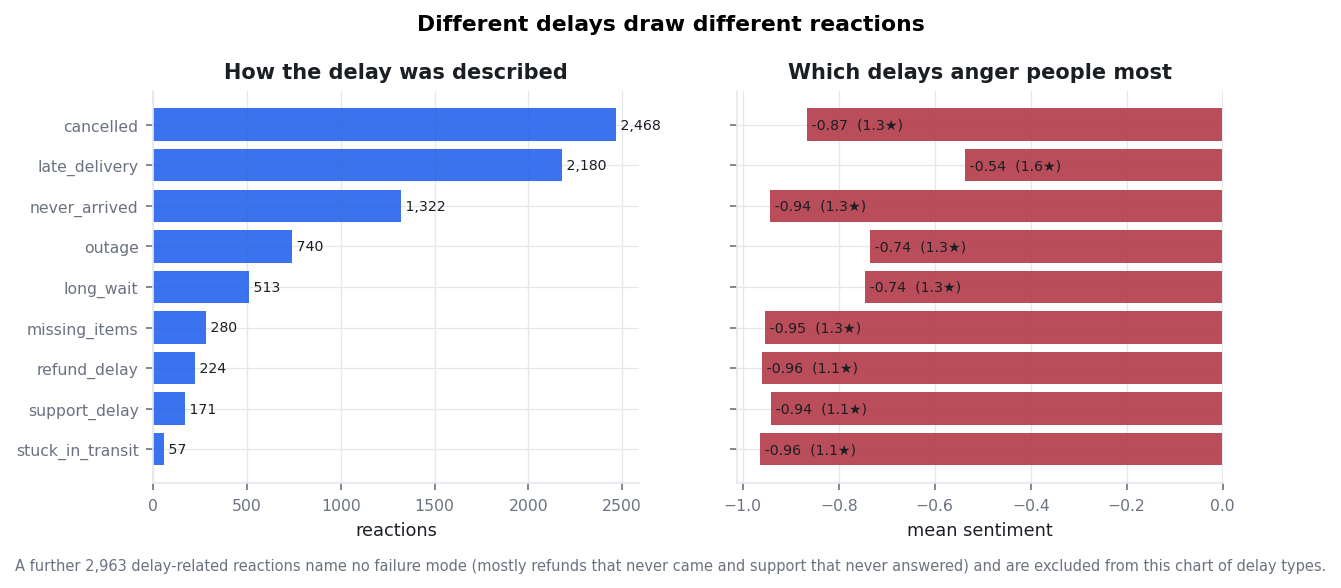

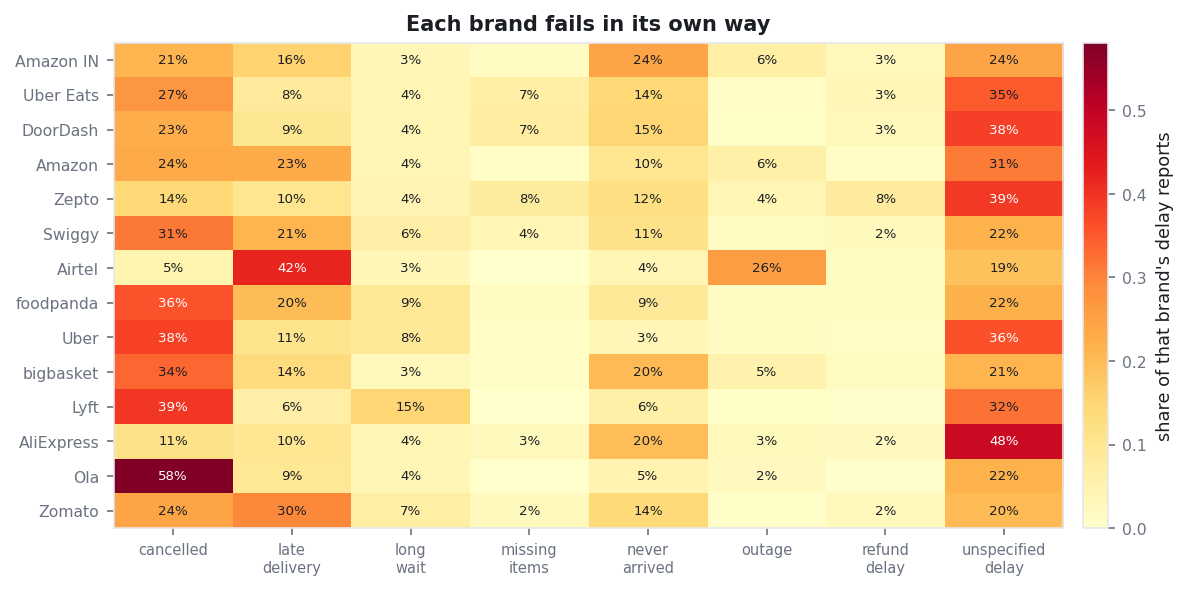

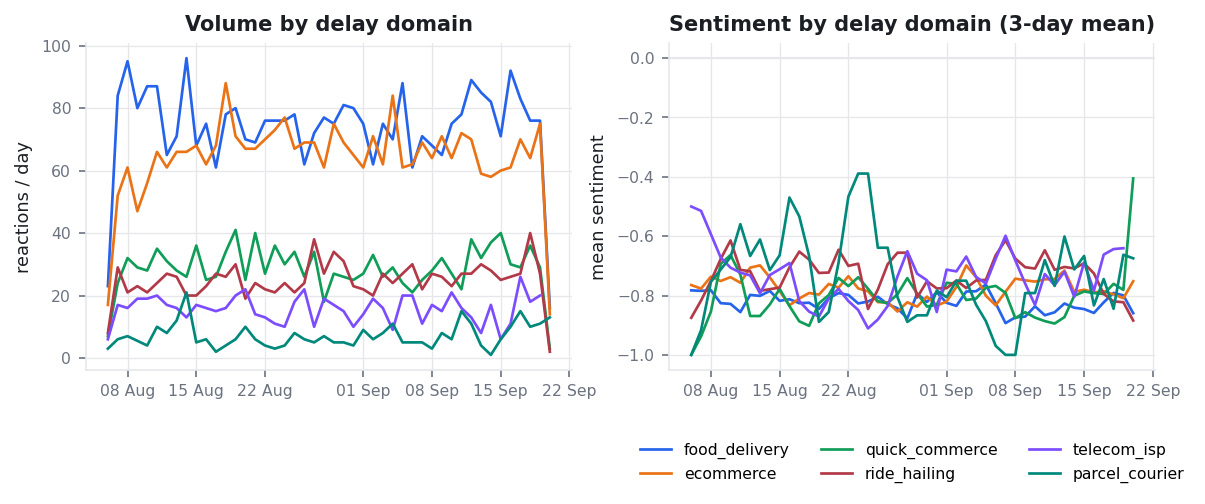

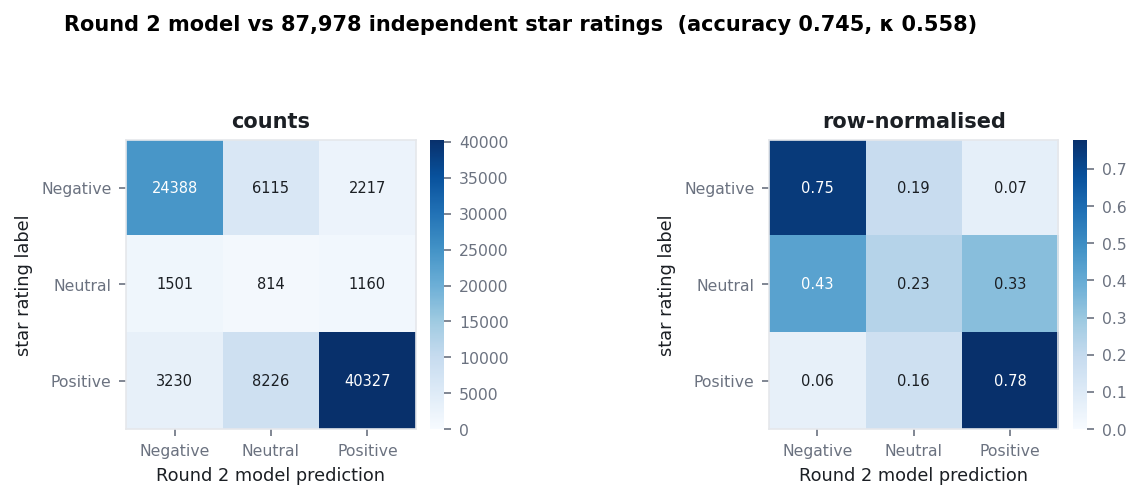

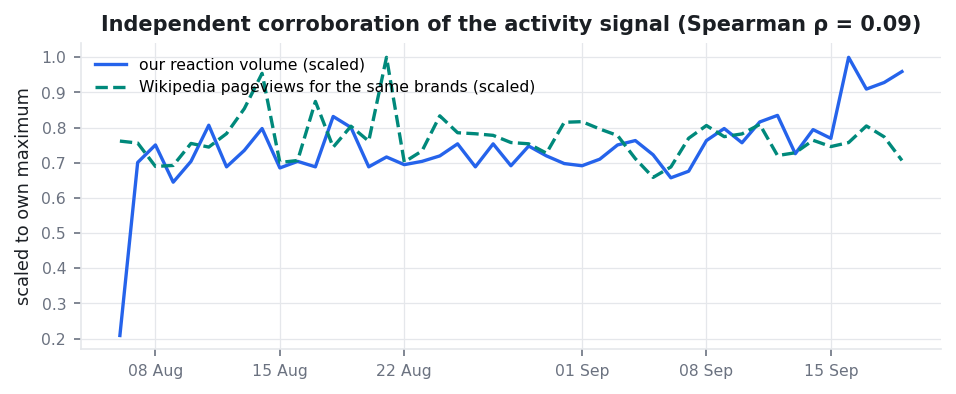

In [30]:
for name in ["fig02_delay_types.png", "fig07_brand_delay_heatmap.png",
             "fig04_domains.png", "fig05_round2_transfer.png",
             "fig10_attention_corroboration.png"]:
    p = REPORTS / "figures" / name
    if p.exists(): display(Image(str(p)))

## 9. What this says about the Social Engine

### What the monitoring layer can do

Shifts and spikes are located statistically rather than by eye; every one
carries the effect it had on reviewers, not just the step it made in a daily
average; every one is re-tested with the panel composition held fixed; and
every one is checked against evidence collected independently of the text that
produced it, with "no external corroboration found" reported as a result rather
than padded.

### What it cannot do, measured rather than asserted

**1. App-store reviews are a slow instrument.** People write a review hours or
days after the failure, and they write one at all only for failures worth the
effort. A six-hour outage that ruins a Friday dinner service produces a burst of
posts on social platforms and barely moves a Play review series. That is a
property of the medium. It sets a floor on the latency of anything built on this
source and it is the reason the collector reaches for Reddit, Lemmy, Mastodon
and Hacker News at all, thin as those layers are.

**2. The operators whose delays people react to do not publish status pages.**
`status.doordash.com`, `status.uber.com`, `status.zomato.com` and
`status.lyft.com` do not resolve. Only infrastructure vendors run public
Statuspage instances. A trigger layer built from status feeds therefore cannot,
*even in principle*, corroborate a food-delivery complaint spike — which is why
the first version of this work found 238 incidents from Discord, Zoom, Dropbox
and GitHub, and correctly used none of them. The roster is now restricted to
vendors that sit in the delivery and commerce chain, and the structural limit is
reported rather than papered over with a coincidence.

**3. The sentiment model is transferring across domains, and Neutral is where
it breaks.** Section 4 measures the cost: 89% on positive-vs-negative,
recall 0.28 and precision 0.06 on Neutral. The model emits far more Neutral
predictions than there are three-star reviews, which drags every daily mean
toward zero by a text-length- and brand-dependent amount. The confidence-gated
series is reported beside the ungated one for that reason.

**4. A 45-day window is a baseline, not an event.** No single named,
externally-documented delivery failure inside this window produced a move in
these reactions that survives the composition control. Reporting one anyway
would have been the easiest thing in this submission to do and the least
defensible.

### What we would do next, in order

1. **Fine-tune on the star ratings.** There are ~91,000 independently labelled
   in-domain examples sitting in the dataset — more in-domain supervision than
   Round 2 ever had — and the Neutral class is precisely where that would pay.
2. **Move the reaction layer off the app stores.** The census fixed the
   *sampling*; it cannot fix the *medium*. Authenticated Reddit, or a paid X
   tier, is what turns this from a review monitor into a conversation monitor.
3. **Page on reply rate, not on sentiment.** `company_replied` moves faster
   than sentiment, is operator-controlled, and needs no model to interpret.

---

**Team SE7EN** — Tanmay Singh · Panshul Arora